In [1]:
# import sys
# !"C:\Users\23521\AppData\Local\Programs\Python\Python313\python.exe" -m pip install tensorflow

# Load dữ liệu

In [2]:
import pandas as pd

train = pd.read_json("./preprocessed-dataset/train_processed.json", lines = True)
dev = pd.read_json("./preprocessed-dataset/dev_processed.json", lines=True)
print(train.head())
print(train["sentiment"].value_counts())


                                              review sentiment
0  khởi_tố bị_can vụ sập hội_trường thị_trấn cơ_q...  negative
1  lãi_suất ngân_hàng hôm_nay băng điều_chỉnh lãi...   neutral
2  vinachem kiên_định mục_tiêu tăng_trưởng phường...  positive
3  vụ cuộn vải bạt rơi ô_tô đè chết nam bảo_vệ kh...  negative
4  cđv bình dương đội nắng săn vé tuyển việt nam_...   neutral
sentiment
neutral     674
negative    529
positive    507
Name: count, dtype: int64


# Tách X (text) và y (nhãn) + mã hoá nhãn

In [3]:
from sklearn.preprocessing import LabelEncoder

# Tách text và nhãn train
X_train_text = train["review"].astype(str)
y_train = train["sentiment"].astype(str)

# Tách text và nhãn dev
X_dev_text = dev["review"].astype(str)
y_dev = dev["sentiment"].astype(str)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_dev_enc = le.transform(y_dev)

print("Classes:", le.classes_)        # ví dụ: ['negative' 'neutral' 'positive']
print("Encoded sample:", y_train_enc[:10])
print(f"Dev shape: {X_dev_text.shape}")

Classes: ['negative' 'neutral' 'positive']
Encoded sample: [0 1 2 0 1 0 2 0 0 0]
Dev shape: (244,)


# Xây pipeline: Logistics Regression, Linear SVM, Text CNN

In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

num_classes = len(le.classes_)

# 1. Pipeline cho Logistic Regression
logreg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        # Các tham số khác của TfidfVectorizer giữ nguyên như file gốc của bạn
        # Ví dụ: min_df, max_df, etc.
    )),
    ("clf", LogisticRegression(
        random_state=42,
        max_iter=1000, # Tăng max_iter để đảm bảo model hội tụ với dữ liệu văn bản
        solver='lbfgs' # Solver phổ biến cho multiclass
    ))
])

# 2. Pipeline cho Linear SVM (Thường dùng LinearSVC cho text classification vì nhanh hơn SVC chuẩn)
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        # Các tham số khác giữ nguyên
    )),
    ("clf", LinearSVC(
        random_state=42,
        tol=1e-5,
        max_iter=1000
    ))
])


GridSearchCV

In [5]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# 1. Cấu hình Cross-Validation (Dùng chung cho cả 2 model)
# --- SỬA CELL CẤU HÌNH CROSS-VALIDATION ---
from sklearn.model_selection import PredefinedSplit
import numpy as np

# 1. Ghép dữ liệu Text (Train + Dev) để đưa vào Pipeline
X_combined_text = pd.concat([X_train_text, X_dev_text], axis=0)
y_combined_enc = np.concatenate([y_train_enc, y_dev_enc], axis=0)

# 2. Tạo chỉ số phân chia (test_fold)
# Giá trị -1: Dùng để Train (không dùng để validate)
# Giá trị 0: Dùng để Validate (Tập Dev)
train_indices = np.full((len(X_train_text),), -1, dtype=int)
dev_indices = np.full((len(X_dev_text),), 0, dtype=int)
test_fold = np.concatenate([train_indices, dev_indices], axis=0)

# 3. Khởi tạo PredefinedSplit
# Khi đưa vào GridSearchCV, nó sẽ train trên phần -1 và tính điểm trên phần 0
ps = PredefinedSplit(test_fold)

print(f"Total samples for tuning: {len(test_fold)}")
print("Cấu hình Tuning: Train trên tập Train, Validate trên tập Dev.")

# ==========================================
# A. GRID SEARCH CHO LOGISTIC REGRESSION
# ==========================================

# C: Nghịch đảo của regularization (C càng nhỏ -> regularization càng mạnh -> giảm overfitting)
param_grid_logreg = {
    "clf__C": [0.1, 1, 10], 
    "clf__solver": ["lbfgs", "liblinear"] # Thử nghiệm các thuật toán tối ưu khác nhau
}

grid_logreg = GridSearchCV(
    estimator=logreg_pipeline, # Pipeline Logistic đã khai báo ở trên
    param_grid=param_grid_logreg,
    scoring="f1_macro",   
    cv=ps,
    n_jobs=-1,
    verbose=2, 
    refit = False
)

Total samples for tuning: 1954
Cấu hình Tuning: Train trên tập Train, Validate trên tập Dev.


In [6]:
grid_logreg.fit(X_combined_text, y_combined_enc)

Fitting 1 folds for each of 6 candidates, totalling 6 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__solver': ['lbfgs', 'liblinear']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,False
,cv,"PredefinedSpl...hape=(1954,)))"
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [7]:
# 1. Lấy bộ tham số tốt nhất
best_params = grid_logreg.best_params_
print("Best Params:", grid_logreg.best_params_)

# 2. Khởi tạo lại mô hình/pipeline mới với tham số đó
logreg_pipeline.set_params(**grid_logreg.best_params_)

# 3. Tự tay fit lại mô hình trên dữ liệu Train (hoặc Train + Dev tùy bạn)
logreg_pipeline.fit(X_train_text, y_train_enc)

Best Params: {'clf__C': 10, 'clf__solver': 'lbfgs'}


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [8]:

# ==========================================
# B. GRID SEARCH CHO LINEAR SVM
# ==========================================

param_grid_svm = {
    "clf__C": [0.1, 1, 10],
    "clf__class_weight": [None, "balanced"] # "balanced" giúp ích nếu dữ liệu bị mất cân bằng
}

grid_svm = GridSearchCV(
    estimator=svm_pipeline, # Pipeline SVM đã khai báo ở trên
    param_grid=param_grid_svm,
    scoring="f1_macro",   
    cv=ps,
    n_jobs=-1,
    verbose=2
)


In [9]:
grid_svm.fit(X_combined_text, y_combined_enc)

Fitting 1 folds for each of 6 candidates, totalling 6 fits


,estimator,Pipeline(step... tol=1e-05))])
,param_grid,"{'clf__C': [0.1, 1, ...], 'clf__class_weight': [None, 'balanced']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,"PredefinedSpl...hape=(1954,)))"
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,input,'content'


In [10]:
# 1. Lấy bộ tham số tốt nhất
best_params = grid_svm.best_params_
print("Best Params:", grid_svm.best_params_)

# 2. Khởi tạo lại mô hình/pipeline mới với tham số đó
svm_pipeline.set_params(**grid_svm.best_params_)

# 3. Tự tay fit lại mô hình trên dữ liệu Train (hoặc Train + Dev tùy bạn)
svm_pipeline.fit(X_train_text, y_train_enc)

Best Params: {'clf__C': 0.1, 'clf__class_weight': 'balanced'}


,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [11]:
# ==========================================
# C. GRID SEARCH CHO Text CNN
# ==========================================

import numpy as np
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout, Concatenate
from scikeras.wrappers import KerasClassifier
from tensorflow.keras.layers import Input # <--- Import thêm cái này

# --- CẤU HÌNH CỐ ĐỊNH ---
MAX_NUM_WORDS = 5000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 300
# num_classes = ... (lấy từ code cũ của bạn)

# 1. Định nghĩa hàm tạo model (cần nhận tham số để tuning)
def create_cnn_model(filters=128, dropout_rate=0.5, 
                      num_classes=3, 
                      input_dim=10000, # MAX_NUM_WORDS
                      emb_dim=100,     # EMBEDDING_DIM
                      input_len=200):  # MAX_SEQUENCE_LENGTH
    
    # 1. Input Layer
    inputs = Input(shape=(input_len,))
    
    # 2. Embedding Layer
    # Nếu chưa có pre-trained, ta vẫn để nó tự học, nhưng cấu hình lại
    embedding = Embedding(input_dim=input_dim, 
                          output_dim=emb_dim, 
                          input_length=input_len)(inputs)
    
    # 3. Multi-Kernel Convolution (Bắt các cụm từ độ dài 2, 3, 4, 5 từ)
    # Đây là kỹ thuật chuẩn của bài báo KimCNN nổi tiếng
    kernel_sizes = [2, 3, 4, 5] 
    conv_blocks = []
    
    for size in kernel_sizes:
        # Chạy song song các Conv1D
        conv = Conv1D(filters=filters, kernel_size=size, activation='relu')(embedding)
        pool = GlobalMaxPooling1D()(conv)
        conv_blocks.append(pool)
    
    # 4. Ghép các kết quả lại (Concatenate)
    concat = Concatenate()(conv_blocks)
    
    # 5. Fully Connected Layers
    x = Dropout(dropout_rate)(concat)
    x = Dense(64, activation='relu')(x) # Thêm 1 lớp Dense trung gian để học đặc trưng tốt hơn
    x = Dropout(dropout_rate)(x)
    
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    
    model.compile(loss='sparse_categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])
    return model


In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_NUM_WORDS = 10000   
MAX_SEQUENCE_LENGTH = 200 

# 1. Tạo và học từ vựng từ X_train_text
tokenizer = Tokenizer(num_words=MAX_NUM_WORDS)
tokenizer.fit_on_texts(X_train_text) 

# 2. Chuyển văn bản thành chuỗi số và padding
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)

X_dev_seq = tokenizer.texts_to_sequences(X_dev_text)
X_dev_pad = pad_sequences(X_dev_seq, maxlen=MAX_SEQUENCE_LENGTH)

# 4. Ghép dữ liệu Pad (Train + Dev) để đưa vào GridSearch CNN
X_combined_pad = np.concatenate([X_train_pad, X_dev_pad], axis=0)

In [13]:
# 1. Khởi tạo lại wrapper
model_wrapper = KerasClassifier(model=create_cnn_model, 
                                verbose=0,
                                num_classes=len(le.classes_),
                                input_dim=MAX_NUM_WORDS,
                                emb_dim=EMBEDDING_DIM,
                                input_len=MAX_SEQUENCE_LENGTH)

# 2. Định nghĩa lại tham số (như cũ)
######## ĐÂY LÀ BEST PARAMS, CHẠY ĐOẠN NÀY CHO NHANH #########
# param_grid = {
#     "model__filters": [64],    # Số lượng bộ lọc
#     "model__dropout_rate": [0.5], # Giảm overfitting
#     "batch_size": [64],         # Batch nhỏ giúp model học kỹ hơn trên data ít
#     "epochs": [30]  
# }

param_grid = {
    "model__filters": [64, 128],    # Số lượng bộ lọc
    "model__dropout_rate": [0.3, 0.5], # Giảm overfitting
    "batch_size": [32, 64],         # Batch nhỏ giúp model học kỹ hơn trên data ít
    "epochs": [20, 30]  
}

# 3. Chạy Grid Search
print("Đang chạy Grid Search CNN trên tập Dev...")
grid = GridSearchCV(
    estimator=model_wrapper,
    param_grid=param_grid,
    scoring='f1_macro',
    refit=False, # Retrain lại model tốt nhất
    cv=ps,      # <--- Dùng PredefinedSplit để chỉ validate trên Dev
    n_jobs=1,   # Keras thường nên để n_jobs=1 để tránh lỗi GPU/Memory
    verbose=1
)

# Đảm bảo X_train_pad là shape (samples, 200) và y_train là int

Đang chạy Grid Search CNN trên tập Dev...


In [14]:
grid.fit(X_combined_pad, y_combined_enc) 

Fitting 1 folds for each of 16 candidates, totalling 16 fits


c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
c:\Users\23521\

,estimator,KerasClassifi..._weight=None )
,param_grid,"{'batch_size': [32, 64], 'epochs': [20, 30], 'model__dropout_rate': [0.3, 0.5], 'model__filters': [64, 128]}"
,scoring,'f1_macro'
,n_jobs,1
,refit,False
,cv,"PredefinedSpl...hape=(1954,)))"
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,model,<function cre...001F3F83EDE40>


In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Lấy tham số tốt nhất
best_params = grid.best_params_
print("Best params:", best_params)

# Tạo model final
final_model = create_cnn_model(
    filters=best_params['model__filters'],
    dropout_rate=best_params['model__dropout_rate'],
    num_classes=len(le.classes_),
    input_dim=MAX_NUM_WORDS,
    emb_dim=EMBEDDING_DIM,
    input_len=MAX_SEQUENCE_LENGTH
)

# Callbacks: Dừng sớm nếu không cải thiện, và giảm learning rate nếu bị kẹt
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-5)
]

# Train trên tập TRAIN, validate trên DEV (giống PhoBERT)
history = final_model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_dev_pad, y_dev_enc),
    epochs=50, # Để dư ra, EarlyStopping sẽ dừng sớm
    batch_size=best_params['batch_size'],
    callbacks=callbacks,
    verbose=1
)

Best params: {'batch_size': 32, 'epochs': 20, 'model__dropout_rate': 0.3, 'model__filters': 64}
Epoch 1/50


c:\Users\23521\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.4111 - loss: 1.0729 - val_accuracy: 0.4672 - val_loss: 1.0069 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 119ms/step - accuracy: 0.6848 - loss: 0.8002 - val_accuracy: 0.6352 - val_loss: 0.7838 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.8573 - loss: 0.4240 - val_accuracy: 0.6762 - val_loss: 0.7639 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9538 - loss: 0.1697 - val_accuracy: 0.6803 - val_loss: 0.8309 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 131ms/step - accuracy: 0.9906 - loss: 0.0614 - val_accuracy: 0.6557 - val_loss: 0.9824 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.9953 - loss: 0.0333 - val_accuracy: 0.6148 - val_loss: 1.1370 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.9977 - loss: 0.0241 - val_accura

In [16]:
print("Best params CNN:", grid.best_params_)
print("Best CV macro-F1 CNN:", grid.best_score_)

Best params CNN: {'batch_size': 32, 'epochs': 20, 'model__dropout_rate': 0.3, 'model__filters': 64}
Best CV macro-F1 CNN: 0.6869142378660856


In [17]:
print("Best params Logistics Regression:", grid_logreg.best_params_)
print("Best CV macro-F1 Logistics Regression:", grid_logreg.best_score_)

Best params Logistics Regression: {'clf__C': 10, 'clf__solver': 'lbfgs'}
Best CV macro-F1 Logistics Regression: 0.7311818438201274


In [18]:
print("Best params Linear SVM:", grid_svm.best_params_)
print("Best CV macro-F1 Linear SVM:", grid_svm.best_score_)

Best params Linear SVM: {'clf__C': 0.1, 'clf__class_weight': 'balanced'}
Best CV macro-F1 Linear SVM: 0.7290811666954061


# Classification report trên tập test

In [19]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


In [20]:
test = pd.read_json("./preprocessed-dataset/test_processed.json",  lines = True)
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)


## test CNN

In [21]:
# 2. Chuyển văn bản thành chuỗi số
X_test_seq = tokenizer.texts_to_sequences(X_test_text)

# 3. Padding (để độ dài bằng nhau là 200) -> ĐÂY MỚI LÀ BIẾN DÙNG ĐỂ TRAIN
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)

y_test_enc = le.transform(y_test_text)
y_pred_enc = final_model.predict(X_test_pad)
y_pred_enc = np.argmax(y_pred_enc, axis=1)
#y_pred_enc = le.transform(y_pred_enc)

acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step
Accuracy trên test: 0.6857
Macro F1 trên test: 0.6853


In [22]:
print("CNN classification report")
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
)
print(report)

CNN classification report
              precision    recall  f1-score   support

    negative       0.70      0.83      0.76       151
     neutral       0.78      0.52      0.62       194
    positive       0.61      0.77      0.68       145

    accuracy                           0.69       490
   macro avg       0.69      0.70      0.69       490
weighted avg       0.70      0.69      0.68       490



<Figure size 600x500 with 0 Axes>

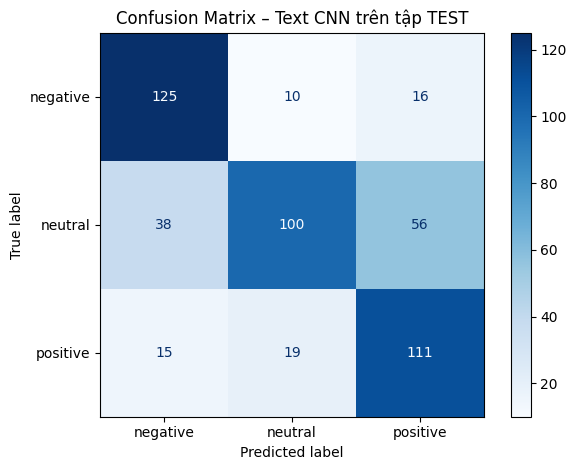

In [23]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title("Confusion Matrix – Text CNN trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [24]:
test = pd.read_json("./preprocessed-dataset/dev_processed.json",  lines = True)
X_dev_text = test["review"].astype(str)
y_dev_text = test["sentiment"].astype(str)


# 2. Chuyển văn bản thành chuỗi số
X_dev_seq = tokenizer.texts_to_sequences(X_dev_text)

# 3. Padding (để độ dài bằng nhau là 200) -> ĐÂY MỚI LÀ BIẾN DÙNG ĐỂ TRAIN
X_dev_pad = pad_sequences(X_dev_seq, maxlen=MAX_SEQUENCE_LENGTH)

y_dev_enc = le.transform(y_dev_text)
y_pred_enc = final_model.predict(X_dev_pad)
y_pred_enc = np.argmax(y_pred_enc, axis=1)
#y_pred_enc = le.transform(y_pred_enc)

acc = accuracy_score(y_dev_enc, y_pred_enc)
f1_macro = f1_score(y_dev_enc, y_pred_enc, average="macro")

print(f"Accuracy trên dev: {acc:.4f}")
print(f"Macro F1 trên dev: {f1_macro:.4f}")

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Accuracy trên dev: 0.6762
Macro F1 trên dev: 0.6755


## Logistics Regression

In [25]:
test = pd.read_json("./preprocessed-dataset/test_processed.json",  lines = True)
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)

y_test_enc = le.transform(y_test_text)

y_pred_enc = logreg_pipeline.predict(X_test_text)
#y_pred_enc = le.transform(y_pred_enc)

In [26]:
acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

Accuracy trên test: 0.7102
Macro F1 trên test: 0.7121


In [27]:
print("CNN classification report")
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
)
print(report)

CNN classification report
              precision    recall  f1-score   support

    negative       0.78      0.75      0.76       151
     neutral       0.70      0.69      0.69       194
    positive       0.66      0.70      0.68       145

    accuracy                           0.71       490
   macro avg       0.71      0.71      0.71       490
weighted avg       0.71      0.71      0.71       490



<Figure size 600x500 with 0 Axes>

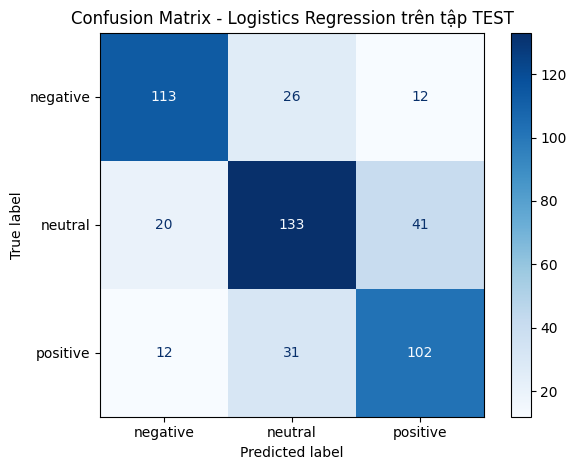

In [28]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title(f"Confusion Matrix - {"Logistics Regression"} trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

In [29]:
test = pd.read_json("./preprocessed-dataset/dev_processed.json",  lines = True)
X_dev_text = test["review"].astype(str)
y_dev_text = test["sentiment"].astype(str)

y_dev_enc = le.transform(y_dev_text)

y_pred_enc = logreg_pipeline.predict(X_dev_text)
#y_pred_enc = le.transform(y_pred_enc)

In [30]:
acc = accuracy_score(y_dev_enc, y_pred_enc)
f1_macro = f1_score(y_dev_enc, y_pred_enc, average="macro")

print(f"Accuracy trên dev: {acc:.4f}")
print(f"Macro F1 trên dev: {f1_macro:.4f}")

Accuracy trên dev: 0.7295
Macro F1 trên dev: 0.7312


## Linear SVM

In [31]:
test = pd.read_json("./preprocessed-dataset/test_processed.json",  lines = True)
X_test_text = test["review"].astype(str)
y_test_text = test["sentiment"].astype(str)

y_test_enc = le.transform(y_test_text)

y_pred_enc = svm_pipeline.predict(X_test_text)
#y_pred_enc = le.transform(y_pred_enc)

In [32]:
acc = accuracy_score(y_test_enc, y_pred_enc)
f1_macro = f1_score(y_test_enc, y_pred_enc, average="macro")

print(f"Accuracy trên test: {acc:.4f}")
print(f"Macro F1 trên test: {f1_macro:.4f}")

Accuracy trên test: 0.7082
Macro F1 trên test: 0.7086


In [33]:
print("CNN classification report")
report = classification_report(
    y_test_enc,
    y_pred_enc,
    target_names=le.classes_
)
print(report)

CNN classification report
              precision    recall  f1-score   support

    negative       0.74      0.77      0.76       151
     neutral       0.72      0.68      0.70       194
    positive       0.66      0.69      0.67       145

    accuracy                           0.71       490
   macro avg       0.71      0.71      0.71       490
weighted avg       0.71      0.71      0.71       490



<Figure size 600x500 with 0 Axes>

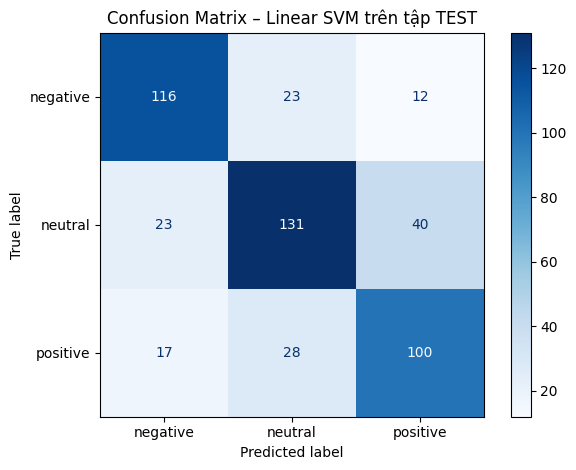

In [34]:
import numpy as np

cm = confusion_matrix(y_test_enc, y_pred_enc)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

plt.figure(figsize=(6, 5))
disp.plot(
    cmap="Blues",          # tông xanh cho dễ nhìn
    values_format="d"      # hiển thị số nguyên
)
plt.title(f"Confusion Matrix – {"Linear SVM"} trên tập TEST")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


In [35]:
dev = pd.read_json("./preprocessed-dataset/dev_processed.json",  lines = True)
X_dev_text = dev["review"].astype(str)
y_dev_text = dev["sentiment"].astype(str)

y_dev_enc = le.transform(y_dev_text)
y_pred_enc = svm_pipeline.predict(X_dev_text)
#y_pred_enc = le.transform(y_pred_enc)

In [36]:
acc = accuracy_score(y_dev_enc, y_pred_enc)
f1_macro = f1_score(y_dev_enc, y_pred_enc, average="macro")

print(f"Accuracy trên dev: {acc:.4f}")
print(f"Macro F1 trên dev: {f1_macro:.4f}")

Accuracy trên dev: 0.7295
Macro F1 trên dev: 0.7291
